# FuseMap Tutorial 9: Beyond the Brain — Whole-Embryo, Cross-Resolution Integration

FuseMap is not brain-specific. This tutorial integrates two **E15.5 whole mouse embryo**
sections measured by completely different technologies:

- **Stereo-seq** (MOSTA atlas, single-cell-binned, 25k genes, with organ annotations)
- **Visium HD** (16 µm bins, mixtures — treated as bead-resolution)

and then transfers **organ labels** from MOSTA onto the un-annotated Visium HD bins.

**Runtime**: integration takes several hours (GPU); `precomputed_output/` ships with the download
so you can skip straight to the analysis. **Tip**: keep all inputs as raw counts — mixing
normalization schemes across datasets degrades integration.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
import numpy as np
import pandas as pd
import scanpy as sc

## 1. Download the example data

In [ ]:
import gdown

FILES = {
    "E15.5_E2S1.MOSTA.h5ad": "1yDxtjvZjZs-gekai7dk9zNjfybW4Nu8L",
    "Mouse_embryo_square_016um.h5ad": "1gNJqse6LA4fwfDp_qwd4_be-rsrlvzI1",
    "precomputed_output/ad_celltype_embedding.h5ad": "1skI2VosIKl9ZoDoUUEL0LljorBJdRiXp",
    "precomputed_output/ad_celltype_embedding_stageB.h5ad": "1RDH_CQTRUTAUJdXsFt44hvx3cVbeeWvA",
    "precomputed_output/ad_gene_embedding.h5ad": "16sqyQqbnTc4-x834F8qIstRu08a6BLVk",
    "precomputed_output/ad_tissueregion_embedding.h5ad": "1rt1sdDIXfOhYR6EmeuqbXuPY4tZX6YMI",
    "precomputed_output/ad_tissueregion_embedding_stageB.h5ad": "1j9CCehmn6vQowD2gDxAe_gW6-xHG4uNC",
    "precomputed_output/stageB_pi.npz": "1IZb6wzAAdkvd2OWdOLmWFNa0vfb83Dr0",
    "precomputed_output/trained_model/FuseMap_final_model_final.pt": "1E4BWWhiJWhXccxxnOSZljDGaR00xgkeu",
}
base = "./tutorial_data/tutorial9_embryo"
for rel, fid in FILES.items():
    out = os.path.join(base, rel)
    if not os.path.exists(out):
        os.makedirs(os.path.dirname(out), exist_ok=True)
        gdown.download(id=fid, output=out, quiet=False)

## 2. Integrate + deconvolve (skipped if precomputed output present)

In [3]:
import fusemap, shutil

if not os.path.exists("./output_tutorial9"):
    shutil.copytree("./tutorial_data/tutorial9_embryo/precomputed_output", "./output_tutorial9")

if not os.path.exists("./output_tutorial9/ad_celltype_embedding.h5ad"):
    fusemap.integrate("./tutorial_data/tutorial9_embryo", "./output_tutorial9")
if not os.path.exists("./output_tutorial9/ad_tissueregion_embedding_stageB.h5ad"):
    fusemap.deconvolve_beads("./output_tutorial9", "./tutorial_data/tutorial9_embryo",
                             bead_files="square_016um", sig_ref="MOSTA")

## 3. Transfer organ labels to the Visium HD bins

Nearest neighbors in the shared **Stage-B tissue embedding**: each Visium bin takes the majority
organ label of its 30 closest MOSTA cells.

In [4]:
import torch

ad_t = sc.read_h5ad("./output_tutorial9/ad_tissueregion_embedding_stageB.h5ad")
is_mo = ad_t.obs["file_name"].str.contains("MOSTA").values
is_vi = ~is_mo

raw_mo = sc.read_h5ad("./tutorial_data/tutorial9_embryo/E15.5_E2S1.MOSTA.h5ad")
organ = raw_mo.obs["annotation"].astype(str).reindex(ad_t.obs_names[is_mo]).values

X = torch.as_tensor(np.asarray(ad_t.X), dtype=torch.float32)
Xm, Xv = X[is_mo], X[is_vi]
pred = []
for s in range(0, Xv.shape[0], 4096):
    idx = torch.cdist(Xv[s:s+4096], Xm).topk(30, largest=False).indices.numpy()
    pred.append(pd.DataFrame(organ[idx]).mode(axis=1)[0].values)
pred = np.concatenate(pred)

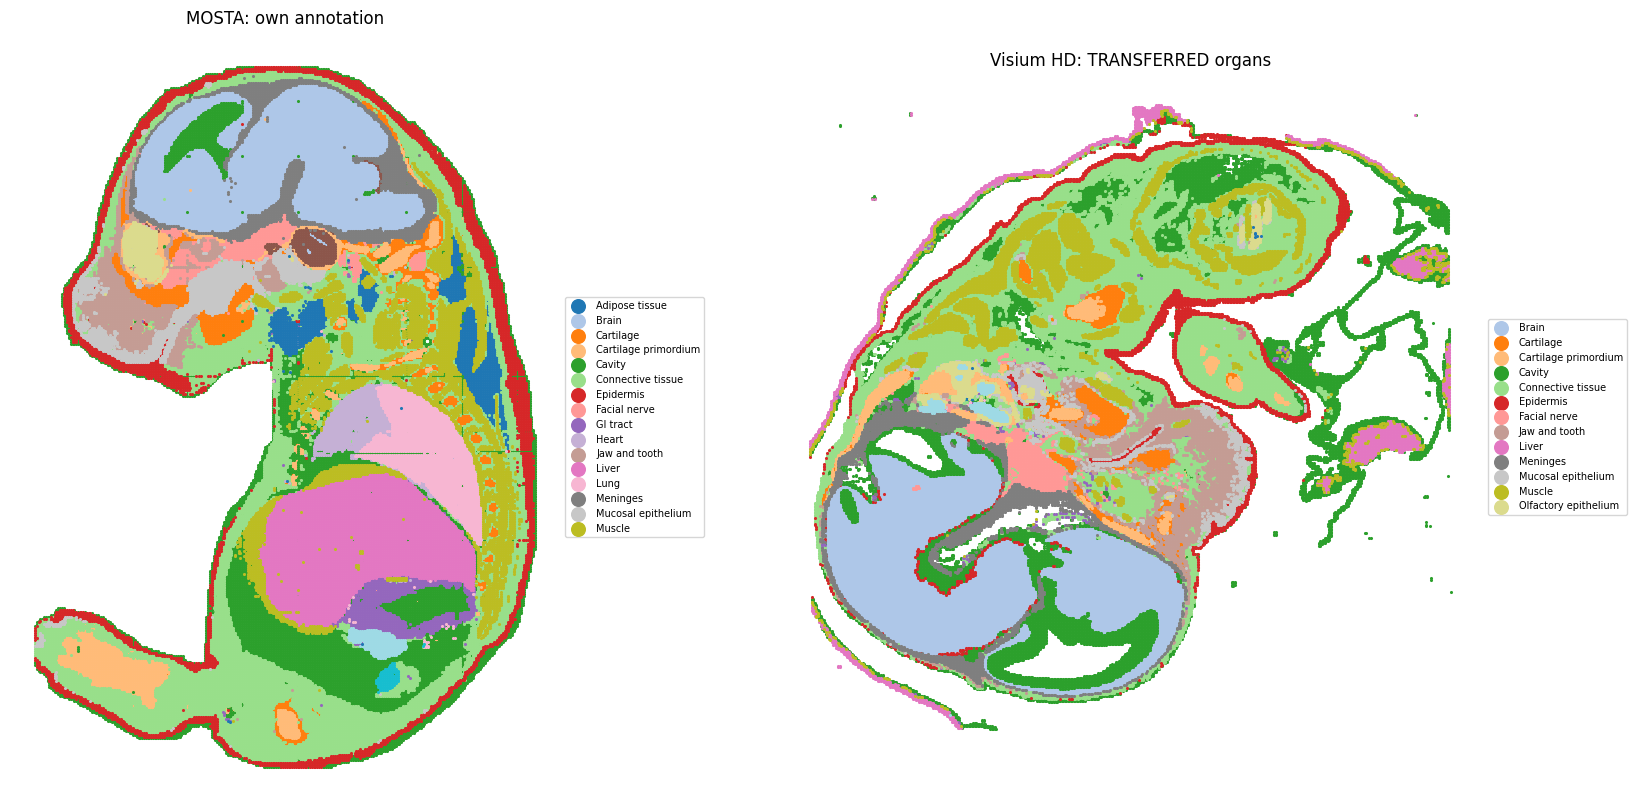

In [5]:
import matplotlib.pyplot as plt

xy = np.c_[pd.to_numeric(ad_t.obs["x"]), pd.to_numeric(ad_t.obs["y"])]
organs = sorted(set(organ))
cmap = plt.get_cmap("tab20")
pal = {o: cmap(i % 20) for i, o in enumerate(organs)}

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
for ax, (m, lab, title) in zip(axes, [(is_mo, organ, "MOSTA: own annotation"),
                                      (is_vi, pred, "Visium HD: TRANSFERRED organs")]):
    sub = xy[m]
    for o in organs:
        mm = lab == o
        if mm.sum():
            ax.scatter(sub[mm, 0], sub[mm, 1], s=1.5, color=pal[o], label=o if mm.sum() > 800 else None)
    ax.set_title(title); ax.set_aspect("equal"); ax.invert_yaxis(); ax.axis("off")
    ax.legend(markerscale=8, fontsize=7, loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

Anatomically coherent organ maps on the Visium HD side (brain, liver, heart in the right
places) confirm that the shared tissue space generalizes across organs, resolutions, and
technologies — with zero brain-specific assumptions.